# 06 - DiD Models, Sample Design, and Early Team Results

This notebook organizes the next stage of the project around two complementary samples:

- **Model 1**: a nationwide border-county main sample used for the headline estimate.
- **Model 2**: a smaller illustrative border sample used for intuition, visuals, and later event-study work.

Recommended environment:
- Any kernel with `pandas`, `numpy`, `pyarrow`, `matplotlib`, and `statsmodels` installed.

Notebook roadmap:
1. Research question
2. Main sample and illustrative sample
3. Model 1: nationwide main specification
4. Early results from Model 1
5. Robustness checks for Model 1
6. Model 2: illustrative border sample
7. Working interpretation for the report
8. What each model is best for next


## 1. Research Question

**Main question:** Does raising the minimum wage reduce employment in low-wage border counties, especially in food services?

We keep `NAICS 722` as the anchor industry because:
- it is the closest match to the classic border-county minimum wage literature,
- it is highly exposed to minimum wage policy,
- and it gives us the clearest first headline result before extending to other sectors.

We also track `log_wage` alongside `log_emp` because wage pass-through is an important first-stage validation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", None)

CWD = Path().resolve()
ROOT = CWD if (CWD / "data" / "intermediate").exists() else CWD.parent
INTERMEDIATE = ROOT / "data" / "intermediate"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

PANEL_FILE = PROCESSED / "analysis_panel.parquet"
PAIRS_FILE = INTERMEDIATE / "border_pairs.parquet"

PRIMARY_INDUSTRY = "722"
INDUSTRIES = ["722", "44-45", "72", "721"]
SELECTED_BORDERS = ["NJ - PA", "MN - WI", "NY - PA", "CA - NV"]

print("Figures will be saved to:", FIGURES)

Figures will be saved to: /Users/banna/Desktop/IDS_701-Causal-Inference_Final/notebooks/figures


## 2. Main Sample and Illustrative Sample

### Model 1: nationwide main sample
This is our preferred sample for the main estimate.
It uses **all eligible border-county pairs nationwide** that appear in the final analysis panel.

### Model 2: illustrative border sample
For visuals and later event-study work, we use four state borders:
- `NJ - PA`
- `MN - WI`
- `NY - PA`
- `CA - NV`

We choose these borders because they combine:
- clear and persistent minimum wage divergence,
- enough county-pair coverage,
- strong data completeness in `NAICS 722`,
- and a close fit with the project's border-county story.

The two models are **complements**, not competing main models:
- **Model 1** estimates the average effect across the nationwide border-county sample.
- **Model 2** gives us a smaller, more intuitive set of border comparisons for plots and extension work.


In [2]:
panel = pd.read_parquet(PANEL_FILE).copy()
pairs = pd.read_parquet(PAIRS_FILE).copy()

panel["industry_code"] = panel["industry_code"].astype(str)
panel["pair_id"] = panel["pair_id"].astype(int)
panel["year"] = panel["year"].astype(int)
panel["pair_year"] = panel["pair_id"].astype(str) + "_" + panel["year"].astype(str)
panel["mw_gap"] = panel["min_wage"] - panel["partner_min_wage"]
panel["mw_gap_abs"] = panel["mw_gap"].abs()
panel["complete_pair_year"] = (
    panel.groupby(["pair_id", "year", "industry_code"])["area_fips"].transform(
        "nunique"
    )
    == 2
)

pairs["border"] = pairs.apply(
    lambda row: " - ".join(sorted([str(row["state1"]), str(row["state2"])])), axis=1
)
panel = panel.merge(pairs[["pair_id", "border"]], on="pair_id", how="left")

main_sample = panel.copy()
main_722 = main_sample.loc[main_sample["industry_code"] == PRIMARY_INDUSTRY].copy()
illustrative_sample = main_sample.loc[
    main_sample["border"].isin(SELECTED_BORDERS)
].copy()
illustrative_722 = illustrative_sample.loc[
    illustrative_sample["industry_code"] == PRIMARY_INDUSTRY
].copy()

sample_summary = pd.DataFrame(
    {
        "rows": [
            len(main_sample),
            len(main_722),
            len(illustrative_sample),
            len(illustrative_722),
        ],
        "pair_ids": [
            main_sample["pair_id"].nunique(),
            main_722["pair_id"].nunique(),
            illustrative_sample["pair_id"].nunique(),
            illustrative_722["pair_id"].nunique(),
        ],
        "counties": [
            main_sample["area_fips"].nunique(),
            main_722["area_fips"].nunique(),
            illustrative_sample["area_fips"].nunique(),
            illustrative_722["area_fips"].nunique(),
        ],
        "borders": [
            main_sample["border"].nunique(),
            main_722["border"].nunique(),
            illustrative_sample["border"].nunique(),
            illustrative_722["border"].nunique(),
        ],
        "years": [
            main_sample["year"].nunique(),
            main_722["year"].nunique(),
            illustrative_sample["year"].nunique(),
            illustrative_722["year"].nunique(),
        ],
        "mean_abs_gap": [
            main_sample["mw_gap_abs"].mean(),
            main_722["mw_gap_abs"].mean(),
            illustrative_sample["mw_gap_abs"].mean(),
            illustrative_722["mw_gap_abs"].mean(),
        ],
    },
    index=["M1 all industries", "M1 NAICS 722", "M2 all industries", "M2 NAICS 722"],
)

sample_summary.round(3)

,rows,pair_ids,counties,borders,years,mean_abs_gap
M1 all industries,156971,1132,1026,103,21,1.264
M1 NAICS 722,39748,1131,1006,103,21,1.263
M2 all industries,11203,70,73,4,21,1.931
M2 NAICS 722,2790,70,73,4,21,1.936


In [3]:
selected_border_summary = (
    illustrative_722.groupby("border")
    .agg(
        county_pairs=("pair_id", "nunique"),
        counties=("area_fips", "nunique"),
        rows=("pair_id", "size"),
        mean_gap=("mw_gap_abs", "mean"),
        max_gap=("mw_gap_abs", "max"),
    )
    .reset_index()
)

selected_pair_year = illustrative_722.groupby(
    ["border", "pair_id", "year"], as_index=False
).agg(
    n_counties=("area_fips", "nunique"),
    min_mw=("min_wage", "min"),
    max_mw=("min_wage", "max"),
)
selected_pair_year["positive_gap"] = (
    selected_pair_year["max_mw"] - selected_pair_year["min_mw"]
) > 0

selected_pair_year_summary = (
    selected_pair_year.groupby("border")
    .agg(
        pair_years=("year", "size"),
        gap_pair_years=("positive_gap", "sum"),
        complete_pair_years=("n_counties", lambda s: (s == 2).sum()),
    )
    .reset_index()
)
selected_pair_year_summary["gap_share"] = (
    selected_pair_year_summary["gap_pair_years"]
    / selected_pair_year_summary["pair_years"]
)
selected_pair_year_summary["complete_share"] = (
    selected_pair_year_summary["complete_pair_years"]
    / selected_pair_year_summary["pair_years"]
)

selected_border_table = selected_border_summary.merge(
    selected_pair_year_summary, on="border"
)
selected_border_table.round(3)

,border,county_pairs,counties,rows,mean_gap,max_gap,pair_years,gap_pair_years,complete_pair_years,gap_share,complete_share
0,CA - NV,17,18,651,2.070,6.00,357,294,294,0.824,0.824
1,MN - WI,23,24,891,1.609,3.60,483,370,408,0.766,0.845
2,NJ - PA,12,13,504,1.879,7.88,252,156,252,0.619,1.000
3,NY - PA,18,19,744,2.249,8.75,378,240,366,0.635,0.968


## 3. Model 1: Nationwide Main Specification

Our preferred main specification is:

$ \log(emp_{cpt}) = \beta \log(mw_{st}) + \alpha_c + \delta_{pt} + \varepsilon_{cpt} $

where:
- `c` = county
- `p` = border pair
- `t` = year
- `alpha_c` = county fixed effects
- `delta_pt` = pair × year fixed effects

Why we use this for **Model 1**:
- county fixed effects absorb permanent county differences,
- pair × year fixed effects keep the comparison local to the same border in the same year,
- and the nationwide sample gives us the cleanest average-effect estimate.

Implementation detail:
- We use `statsmodels` for estimation and clustered standard errors.
- We first absorb the high-dimensional fixed effects by iterative demeaning, then run OLS on the residualized variables.


In [4]:
def alternating_demean(frame, value_cols, fe_cols, max_iter=200, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    last_delta = np.nan

    for n_iter in range(1, max_iter + 1):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        last_delta = float(np.max(np.abs(resid.to_numpy() - prev)))
        if last_delta < tol:
            break

    return resid, n_iter, last_delta


def absorbed_ols(frame, y_col, x_col, fe_cols, cluster_col):
    resid, n_iter, last_delta = alternating_demean(frame, [y_col, x_col], fe_cols)
    y_tilde = resid[y_col]
    x_tilde = resid[[x_col]]

    fit = sm.OLS(y_tilde, x_tilde).fit(
        cov_type="cluster",
        cov_kwds={"groups": frame[cluster_col]},
    )

    ssr = float(np.sum((y_tilde - fit.fittedvalues) ** 2))
    sst = float(np.sum(y_tilde**2))
    within_r2 = np.nan if sst == 0 else 1 - ssr / sst

    return {
        "fit": fit,
        "beta": float(fit.params[x_col]),
        "se": float(fit.bse[x_col]),
        "t_stat": float(fit.tvalues[x_col]),
        "p_value": float(fit.pvalues[x_col]),
        "within_r2": within_r2,
        "n_obs": int(fit.nobs),
        "n_clusters": int(pd.Series(frame[cluster_col]).nunique()),
        "absorbing_iterations": n_iter,
        "final_delta": last_delta,
    }


def tidy_result(label, result):
    return {
        "model": label,
        "beta": result["beta"],
        "cluster_se": result["se"],
        "t_stat": result["t_stat"],
        "p_value": result["p_value"],
        "within_r2": result["within_r2"],
        "n_obs": result["n_obs"],
        "n_clusters": result["n_clusters"],
    }


model1_emp_722 = absorbed_ols(
    main_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model1_wage_722 = absorbed_ols(
    main_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

headline_results = pd.DataFrame(
    [
        tidy_result("M1 722 employment", model1_emp_722),
        tidy_result("M1 722 wages", model1_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    headline_results[col] = headline_results[col].round(4)

headline_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M1 722 employment,-0.0206,0.0189,-1.0907,0.2754,0.0004,39748,1131
1,M1 722 wages,0.1217,0.0099,12.3428,0.0000,0.0427,39748,1131


## 4. Early Results From Model 1

At this stage we want a **team-readable first look**, not a polished final table.

The cells below do two things:
- compare employment and wage elasticities across the four industry definitions,
- and produce a simple coefficient chart so the team can quickly see where the strongest patterns are.

How to read these results:
- `log_wage` is our pass-through / first-stage check.
- `log_emp` is our main outcome.
- `722` is still the anchor industry for interpretation.

Important note on industry scope:
- `72` is a broader aggregate that overlaps with `721` and `722`.
- We therefore use `722` as the anchor result and treat the other rows as heterogeneity or benchmark checks, not four fully independent industries.


In [5]:
industry_results = []
for industry in INDUSTRIES:
    sample = main_sample.loc[main_sample["industry_code"] == industry].copy()
    emp_result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    wage_result = absorbed_ols(
        sample,
        y_col="log_wage",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    industry_results.append(
        {
            "industry_code": industry,
            "n_rows": len(sample),
            "pair_ids": sample["pair_id"].nunique(),
            "emp_beta": emp_result["beta"],
            "emp_se": emp_result["se"],
            "wage_beta": wage_result["beta"],
            "wage_se": wage_result["se"],
        }
    )

industry_results = pd.DataFrame(industry_results)
for col in ["emp_beta", "emp_se", "wage_beta", "wage_se"]:
    industry_results[col] = industry_results[col].round(4)

industry_results

,industry_code,n_rows,pair_ids,emp_beta,emp_se,wage_beta,wage_se
0,722,39748,1131,-0.0206,0.0189,0.1217,0.0099
1,44-45,46904,1132,-0.0037,0.0130,0.0286,0.0076
2,72,37739,1124,-0.0143,0.0190,0.1076,0.0122
3,721,32580,1072,-0.0336,0.0455,0.0499,0.0184


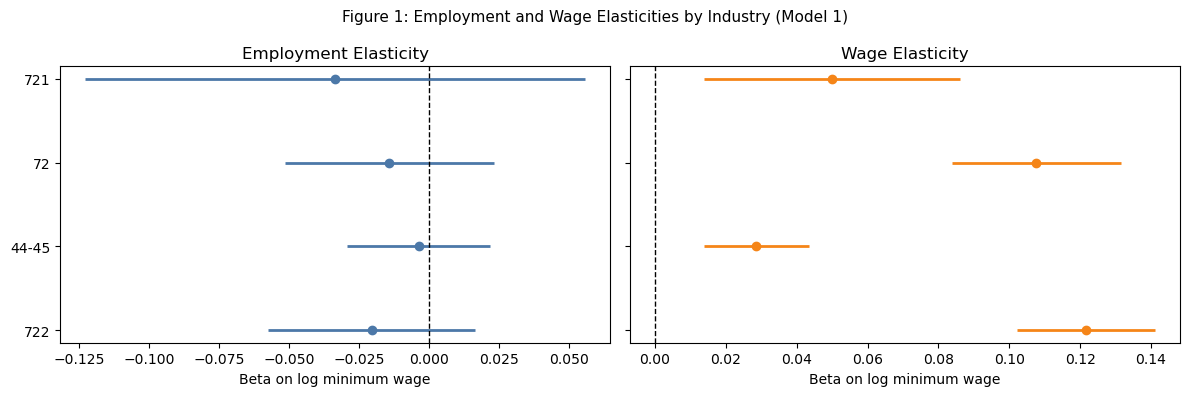

Figure 1 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_df = industry_results.copy()
plot_df["emp_lo"] = plot_df["emp_beta"] - 1.96 * plot_df["emp_se"]
plot_df["emp_hi"] = plot_df["emp_beta"] + 1.96 * plot_df["emp_se"]
plot_df["wage_lo"] = plot_df["wage_beta"] - 1.96 * plot_df["wage_se"]
plot_df["wage_hi"] = plot_df["wage_beta"] + 1.96 * plot_df["wage_se"]

y = np.arange(len(plot_df))

axes[0].hlines(y, plot_df["emp_lo"], plot_df["emp_hi"], color="#4C78A8", lw=2)
axes[0].plot(plot_df["emp_beta"], y, "o", color="#4C78A8")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_title("Employment Elasticity")
axes[0].set_xlabel("Beta on log minimum wage")
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df["industry_code"])

axes[1].hlines(y, plot_df["wage_lo"], plot_df["wage_hi"], color="#F58518", lw=2)
axes[1].plot(plot_df["wage_beta"], y, "o", color="#F58518")
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set_title("Wage Elasticity")
axes[1].set_xlabel("Beta on log minimum wage")
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_df["industry_code"])

plt.suptitle(
    "Figure 1: Employment and Wage Elasticities by Industry (Model 1)", fontsize=11
)
plt.tight_layout()
plt.savefig(FIGURES / "fig1_industry_elasticities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

**How to read Figure 1:** Wage elasticities are clearly positive across all four industry definitions, with the strongest pass-through in `722` and `72`. Employment elasticities, by contrast, stay close to zero and have much wider uncertainty bands. This is why the current evidence is strongest on wage pass-through and more cautious on employment loss.


## 5. Robustness Checks for Model 1

Before treating Model 1 as the headline estimate, we check whether the `NAICS 722` result is sensitive to:
- the clustering level (`pair_id` vs `area_fips`),
- the fixed-effects structure,
- dropping 2020,
- and restricting to complete pair-years with both sides observed.

These are lightweight decision-making checks for the team, not the final exhaustive appendix.


In [7]:
model1_cluster_sensitivity = []
for outcome, outcome_label in [("log_emp", "Employment"), ("log_wage", "Wage")]:
    for cluster_col, cluster_label in [
        ("pair_id", "pair_id"),
        ("area_fips", "area_fips"),
    ]:
        result = absorbed_ols(
            main_722,
            y_col=outcome,
            x_col="log_min_wage",
            fe_cols=["area_fips", "pair_year"],
            cluster_col=cluster_col,
        )
        model1_cluster_sensitivity.append(
            {
                "outcome": outcome_label,
                "cluster": cluster_label,
                "beta": result["beta"],
                "se": result["se"],
                "t_stat": result["t_stat"],
                "p_value": result["p_value"],
                "clusters": result["n_clusters"],
            }
        )

model1_cluster_sensitivity = pd.DataFrame(model1_cluster_sensitivity)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_cluster_sensitivity[col] = model1_cluster_sensitivity[col].round(4)

model1_cluster_sensitivity

,outcome,cluster,beta,se,t_stat,p_value,clusters
0,Employment,pair_id,-0.0206,0.0189,-1.0907,0.2754,1131
1,Employment,area_fips,-0.0206,0.0171,-1.2090,0.2267,1006
2,Wage,pair_id,0.1217,0.0099,12.3428,0.0000,1131
3,Wage,area_fips,0.1217,0.0091,13.4105,0.0000,1006


In [8]:
model1_spec_checks = []
for spec_label, sample, fe_cols, cluster_col in [
    ("county FE + year FE", main_722, ["area_fips", "year"], "area_fips"),
    ("preferred FE", main_722, ["area_fips", "pair_year"], "pair_id"),
    (
        "preferred FE, drop 2020",
        main_722.loc[main_722["year"] != 2020].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
    (
        "preferred FE, complete pair-years",
        main_722.loc[main_722["complete_pair_year"]].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
]:
    result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=fe_cols,
        cluster_col=cluster_col,
    )
    model1_spec_checks.append(
        {
            "spec": spec_label,
            "beta": result["beta"],
            "se": result["se"],
            "t_stat": result["t_stat"],
            "p_value": result["p_value"],
            "n_obs": result["n_obs"],
            "clusters": result["n_clusters"],
        }
    )

model1_spec_checks = pd.DataFrame(model1_spec_checks)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_spec_checks[col] = model1_spec_checks[col].round(4)

model1_spec_checks

,spec,beta,se,t_stat,p_value,n_obs,clusters
0,county FE + year FE,-0.0764,0.0220,-3.4740,0.0005,39748,1006
1,preferred FE,-0.0206,0.0189,-1.0907,0.2754,39748,1131
2,"preferred FE, drop 2020",-0.0160,0.0190,-0.8399,0.4009,37849,1131
3,"preferred FE, complete pair-years",-0.0207,0.0189,-1.0929,0.2744,33782,1064


**How to read the robustness tables:** The `722` employment coefficient stays negative but modest across the main checks. Changing the clustering level slightly changes the standard error but not the basic conclusion. Dropping 2020 and restricting to complete pair-years also leave the estimate in roughly the same range. This suggests the current headline result is not being driven by a single year or a single sample filter.


## 6. Model 2: Illustrative Border Sample

For Model 2, we keep the same general identification idea but restrict attention to four illustrative borders:
- `NJ - PA`
- `MN - WI`
- `NY - PA`
- `CA - NV`

This sample is not meant to replace the nationwide main estimate.
Instead, it is meant to help with:
- intuitive border-by-border visuals,
- later event-study graphs,
- and a more concrete discussion of local comparability.

Because the number of pair clusters is much smaller here, the Model 2 coefficients should be treated as **descriptive and visual support**, not as the main source of statistical inference.


In [9]:
model2_emp_722 = absorbed_ols(
    illustrative_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_wage_722 = absorbed_ols(
    illustrative_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_results = pd.DataFrame(
    [
        tidy_result("M2 722 employment", model2_emp_722),
        tidy_result("M2 722 wages", model2_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    model2_results[col] = model2_results[col].round(4)

model2_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M2 722 employment,-0.0216,0.0329,-0.6553,0.5122,0.0014,2790,70
1,M2 722 wages,0.1794,0.0218,8.2217,0.0000,0.2172,2790,70


In [10]:
by_border_results = []
for border in SELECTED_BORDERS:
    border_sample = illustrative_722.loc[illustrative_722["border"] == border].copy()
    border_emp = absorbed_ols(
        border_sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    by_border_results.append(
        {
            "border": border,
            "pair_ids": border_sample["pair_id"].nunique(),
            "n_rows": len(border_sample),
            "emp_beta": border_emp["beta"],
            "emp_se": border_emp["se"],
        }
    )

by_border_results = pd.DataFrame(by_border_results)
for col in ["emp_beta", "emp_se"]:
    by_border_results[col] = by_border_results[col].round(4)

by_border_results

,border,pair_ids,n_rows,emp_beta,emp_se
0,NJ - PA,12,504,-0.1082,0.0393
1,MN - WI,23,891,-0.0023,0.0658
2,NY - PA,18,744,-0.0191,0.0537
3,CA - NV,17,651,0.1317,0.1606


Absorbing FEs for illustrative event study...
Done.
 rel_time    beta     se
        0  0.0000 0.0000
        1 -0.0081 0.0148
        2 -0.0155 0.0179
        3  0.0101 0.0244
        4 -0.0196 0.0105


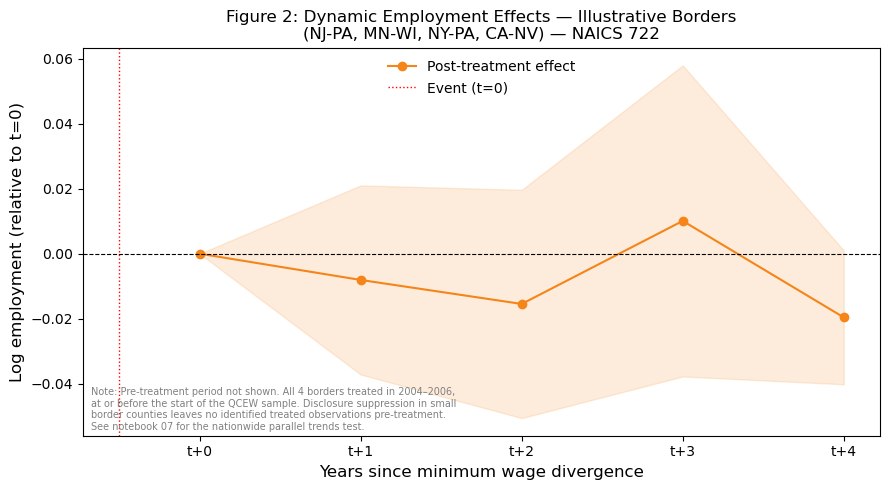

Figure 2 saved.


In [ ]:
# ------------------------------------------------------------------
# Changes 14 + 17: Figure 2 redone as event study
#   - x-axis: time-since-adoption (rel_time), t=0 onward
#   - uncertainty bands from clustered SEs
#   - scoped to the 4 illustrative borders only
#
# Why no pre-period:
# All 4 illustrative borders (NJ-PA, MN-WI, NY-PA, CA-NV) have
# event years in 2004-2006, which is at or near the start of the
# QCEW sample (2004). Additionally, QCEW disclosure suppression
# means that treated-side counties in small border pairs are
# missing in early years, leaving zero treated observations at
# rel_time < 0. The pre-period is therefore unidentified for
# these specific borders.
#
# The formal parallel trends test is conducted on the full
# nationwide sample in notebook 07, where pairs with later
# event years provide genuine pre-treatment variation.
# ------------------------------------------------------------------

ILLUS_POST_PERIODS = 4

# --- 1. Build event year per pair ---
df_illus = illustrative_722[illustrative_722["complete_pair_year"] == True].copy()
df_illus["mw_gap"] = df_illus["min_wage"] - df_illus["partner_min_wage"]

pair_gap = (
    df_illus.groupby(["pair_id", "year"])["mw_gap"]
    .apply(lambda x: x.abs().max())
    .reset_index()
    .rename(columns={"mw_gap": "abs_gap"})
)
event_yrs = (
    pair_gap[pair_gap["abs_gap"] > 0]
    .groupby("pair_id")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "event_year"})
)
df_illus = df_illus.merge(event_yrs, on="pair_id", how="inner")
df_illus["rel_time"] = df_illus["year"] - df_illus["event_year"]

# Restrict to post-treatment only (rel_time >= 0)
df_illus_post = df_illus[df_illus["rel_time"] >= 0].copy()
df_illus_post["rel_time_binned"] = df_illus_post["rel_time"].clip(0, ILLUS_POST_PERIODS)

# --- 2. Build event-study dummies, t=0 omitted base ---
rel_times_post = list(range(1, ILLUS_POST_PERIODS + 1))
for t in rel_times_post:
    df_illus_post["D_" + str(t)] = (
        (df_illus_post["treated"] == 1) & (df_illus_post["rel_time_binned"] == t)
    ).astype(float)
dummy_cols_illus = ["D_" + str(t) for t in rel_times_post]


# --- 3. Absorb FEs: county + pair + year ---
def demean_illus(frame, value_cols, fe_cols, max_iter=300, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    for _ in range(max_iter):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        if np.max(np.abs(resid.to_numpy() - prev)) < tol:
            break
    return resid


print("Absorbing FEs for illustrative event study...")
resid_illus = demean_illus(
    df_illus_post,
    ["log_emp"] + dummy_cols_illus,
    ["area_fips", "pair_id", "year"],
)
print("Done.")

fit_illus = sm.OLS(resid_illus["log_emp"], resid_illus[dummy_cols_illus]).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_illus_post["pair_id"]},
)

# --- 4. Results table (insert t=0 as base, beta=0) ---
res_illus = pd.DataFrame(
    {
        "rel_time": rel_times_post,
        "beta": fit_illus.params[dummy_cols_illus].values,
        "se": fit_illus.bse[dummy_cols_illus].values,
    }
)
res_illus = (
    pd.concat(
        [res_illus, pd.DataFrame({"rel_time": [0], "beta": [0.0], "se": [0.0]})],
        ignore_index=True,
    )
    .sort_values("rel_time")
    .reset_index(drop=True)
)
res_illus["ci_lo"] = res_illus["beta"] - 1.96 * res_illus["se"]
res_illus["ci_hi"] = res_illus["beta"] + 1.96 * res_illus["se"]

print(res_illus[["rel_time", "beta", "se"]].round(4).to_string(index=False))

# --- 5. Plot ---
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.fill_between(
    res_illus["rel_time"],
    res_illus["ci_lo"],
    res_illus["ci_hi"],
    alpha=0.15,
    color="#F58518",
)
ax2.plot(
    res_illus["rel_time"],
    res_illus["beta"],
    marker="o",
    color="#F58518",
    label="Post-treatment effect",
)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(-0.5, color="red", linewidth=1, linestyle=":", label="Event (t=0)")
ax2.set_xlabel("Years since minimum wage divergence", fontsize=12)
ax2.set_ylabel("Log employment (relative to t=0)", fontsize=12)
ax2.set_title(
    "Figure 2: Dynamic Employment Effects — Illustrative Borders\n"
    "(NJ-PA, MN-WI, NY-PA, CA-NV) — NAICS 722",
    fontsize=12,
)
ax2.set_xticks(res_illus["rel_time"])
ax2.set_xticklabels(["t+" + str(t) for t in res_illus["rel_time"]])
ax2.legend(frameon=False)
ax2.annotate(
    "Note: Pre-treatment period not shown. All 4 borders treated in 2004–2006,\n"
    "at or before the start of the QCEW sample. Disclosure suppression in small\n"
    "border counties leaves no identified treated observations pre-treatment.\n"
    "See notebook 07 for the nationwide parallel trends test.",
    xy=(0.01, 0.01),
    xycoords="axes fraction",
    fontsize=7,
    color="gray",
    va="bottom",
)
plt.tight_layout()
plt.savefig(FIGURES / "fig2_event_study_illustrative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

**How to read Figure 2:** This plot shows the dynamic employment effect
in the four illustrative borders (NJ-PA, MN-WI, NY-PA, CA-NV) in the years
following minimum wage divergence. The pre-treatment period is omitted because
all four borders experienced their first minimum wage divergence in 2004–2006,
at or near the start of the QCEW sample. Additionally, QCEW disclosure
suppression in small border counties leaves no identified treated-side
observations in the pre-period. The formal parallel trends test using the
full nationwide sample is presented in notebook 07. Post-treatment coefficients
are small and statistically imprecise (wide confidence bands), consistent with
the headline Model 1 result of no large employment losses in food services.


## 7. Working Interpretation for the Report

Current takeaways from this notebook:
- In **Model 1**, the wage elasticity in `NAICS 722` is clearly positive and precisely estimated. This is strong evidence of wage pass-through.
- The employment elasticity in `NAICS 722` is negative in sign but small and statistically imprecise. The safe wording is that we find **little evidence of large employment losses**, not that we have proven a statistically significant decline.
- The selected-border **Model 2** points in the same general direction as Model 1 for `722`, but the smaller sample makes those estimates noisier.
- Across industries, wage effects are consistently positive. Employment effects remain close to zero or mildly negative.
- Because `72` overlaps with `721` and `722`, it should be described as a broader benchmark rather than a separate independent sector.
- Border-specific estimates, especially for a single border, should be interpreted cautiously because they are based on relatively few clusters.

Suggested report language:

> Our nationwide border-county specification finds strong evidence that minimum wage increases raise wages in food services, while the corresponding employment estimates are small, negative in sign, and statistically imprecise. In other words, the data support clear wage pass-through but provide limited evidence of large employment losses in NAICS 722.


## 8. How to Use These Results

### Model 1: nationwide main sample
Use this as the headline specification for:
- the main employment estimate,
- the wage pass-through result,
- industry heterogeneity,
- and formal robustness checks.

### Model 2: illustrative border sample
Use this for:
- intuitive visuals,
- local trend discussion,
- event-study implementation,
- and showing readers what the border comparison looks like in concrete cases.
